# Final adaptive-PDHG (A) visual check

This notebook runs the selected production path only: image-adaptive directions and regularization, 2×2 local tile weights, multi-direction PDHG, and residual refinement. `sample_01` already contains real stripes, so it is shown without synthetic stripe injection.

In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from destripe import destripe
from destripe.adaptive import estimate_adaptive_params
from destripe.preprocess import prepare_solver_gray

In [2]:
paths = sorted((ROOT / 'asset').glob('sample_*'))
[(path.name, path.stat().st_size) for path in paths]

[('sample_01.jpeg', 74416),
 ('sample_02.tif', 2462766),
 ('sample_03.tif', 2462753),
 ('sample_04.tif', 2462802),
 ('sample_05.tif', 2462759)]

In [3]:
def read_gray(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f'Could not read {path}')
    return image

def show_result(path, process_size=512):
    image = read_gray(path)
    clean = destripe(image, process_size=process_size)
    normalized = image.astype(np.float64) / 255.0
    solver_gray = prepare_solver_gray(gray=normalized, process_size=process_size)
    metadata = estimate_adaptive_params(solver_gray)
    correction = image.astype(np.float64) - clean.astype(np.float64)
    scale = max(float(np.percentile(np.abs(correction), 99)), 1e-6)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'Input: {path.name}')
    axes[1].imshow(clean, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title('Final A output')
    axes[2].imshow(correction, cmap='coolwarm', vmin=-scale, vmax=scale)
    axes[2].set_title('Removed component')
    for axis in axes:
        axis.axis('off')
    plt.tight_layout()
    plt.show()
    return {
        'directions': metadata.directions,
        'mu1': metadata.mu1,
        'mu2': metadata.mu2,
        'confidence': metadata.confidence,
        'correction_rms_8bit': float(np.sqrt(np.mean(correction**2))),
    }

## Real striped baseline

No synthetic corruption is added to `sample_01`; the correction below is produced from the stripes already present in the source image.

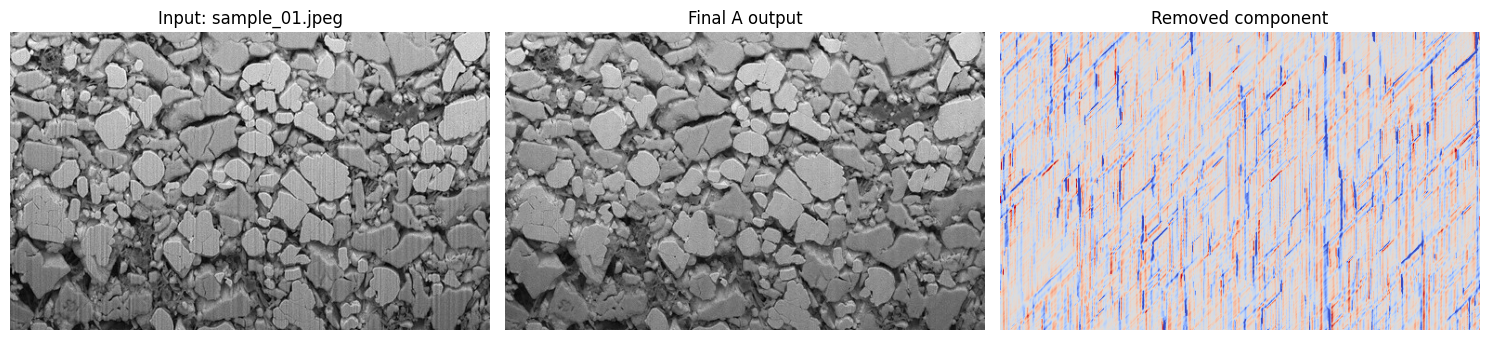

{'directions': (0, 4),
 'mu1': 0.25,
 'mu2': 0.01,
 'confidence': 0.23313117352182924,
 'correction_rms_8bit': 8.897370674900387}

In [4]:
sample_01 = next(path for path in paths if path.stem == 'sample_01')
show_result(sample_01)

## Remaining SEM samples

These views are qualitative preservation checks. They are not treated as paired ground truth.

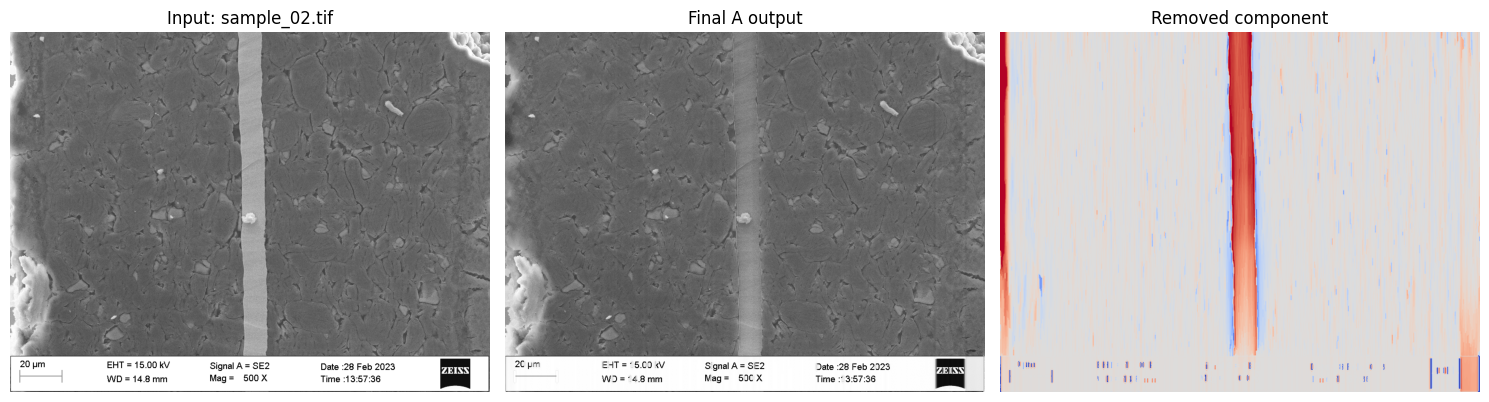

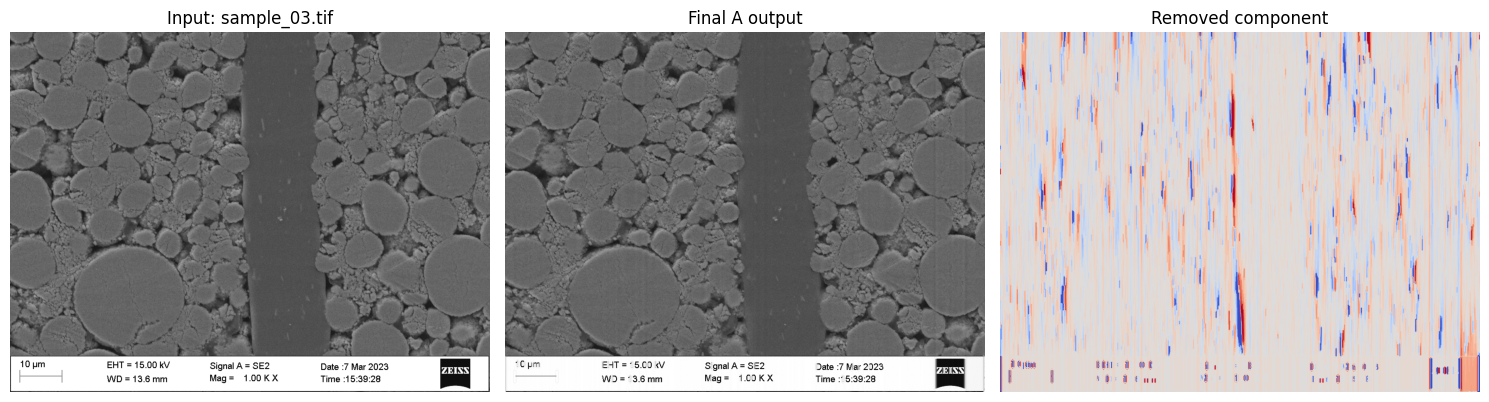

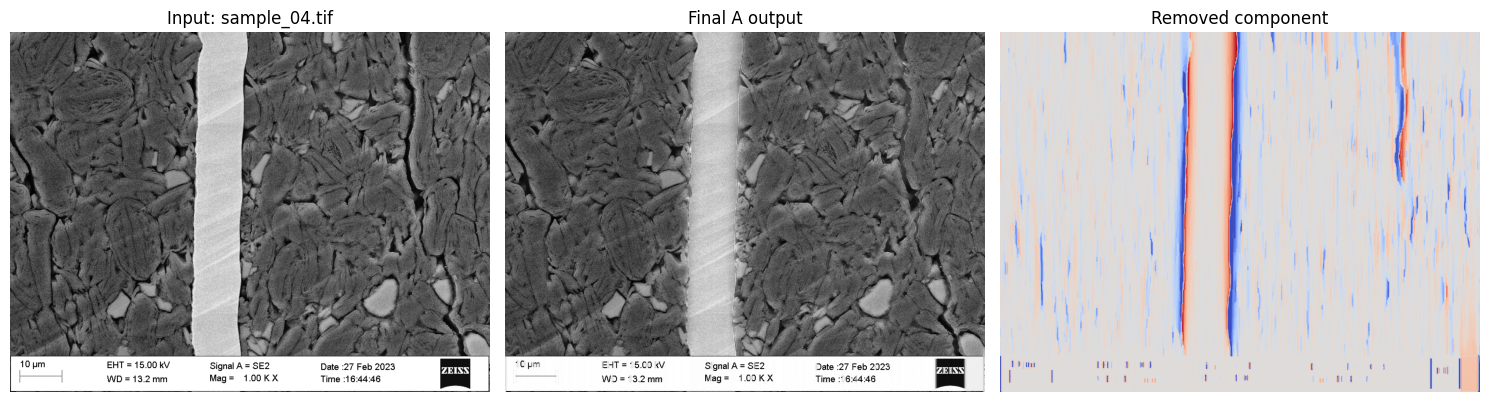

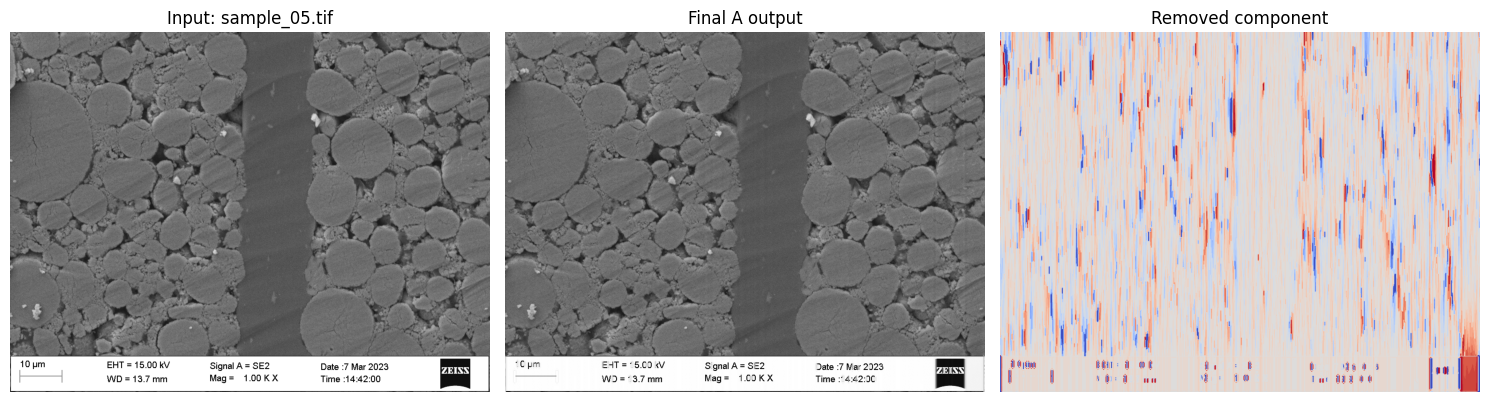

{'sample_02.tif': {'directions': (0,),
  'mu1': 0.25,
  'mu2': 0.0033333333333333335,
  'confidence': 0.2785990165513853,
  'correction_rms_8bit': 11.994039485711829},
 'sample_03.tif': {'directions': (0,),
  'mu1': 0.25,
  'mu2': 0.0033333333333333335,
  'confidence': 0.24111861937627346,
  'correction_rms_8bit': 7.476512413162733},
 'sample_04.tif': {'directions': (0,),
  'mu1': 0.25,
  'mu2': 0.0033333333333333335,
  'confidence': 0.2777958515406949,
  'correction_rms_8bit': 13.7367753675147},
 'sample_05.tif': {'directions': (0,),
  'mu1': 0.25,
  'mu2': 0.0033333333333333335,
  'confidence': 0.2465265543799598,
  'correction_rms_8bit': 7.277843546226424}}

In [5]:
results = {}
for path in paths:
    if path != sample_01:
        results[path.name] = show_result(path)
results